# E-Commerce Sales — Data Cleaning & Visualization

**Project Goal:** Take a raw dataset, clean and process it using Python, analyze the data, create meaningful visualizations, and present useful insights.

**Dataset:** India retail order data (2018), combining two source files:
- `List_of_Orders.csv` — order metadata (Order ID, Order Date, Customer Name, State, City)
- `Order_Details.csv` — order line items (Amount, Profit, Quantity, Category, Sub-Category, Payment Mode)

Both files live in `data/raw/` and are **unmodified originals**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

## 1. Load & Understand the Raw Data

In [2]:
orders_raw = pd.read_csv("../data/raw/List_of_Orders.csv")
details_raw = pd.read_csv("../data/raw/Order_Details.csv")

print("Orders shape:", orders_raw.shape)
print("Details shape:", details_raw.shape)

Orders shape: (560, 5)
Details shape: (764, 7)


In [3]:
orders_raw.head()

,Order ID,Order Date,CustomerName,State,City
0,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad
1,B-25602,01-04-2018,Pearl,Maharashtra,Pune
2,B-25603,03-04-2018,Jahan,Madhya Pradesh,Bhopal
3,B-25604,03-04-2018,Divsha,Rajasthan,Jaipur
4,B-25605,05-04-2018,Kasheen,West Bengal,Kolkata


In [4]:
details_raw.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode
0,B-25953,NaN,-178.94,4,Electronic,Phones,COD
1,B-25617,19677.31,2303.13,4,Electronics,Phones,cod
2,B-25699,28008.45,3885.98,3,furniture,Tables,cod
3,B-25964,251679.20,4425.02,7,Furniture,Chairs,EMI
4,B-25734,6149.18,1244.98,5,CLOTHING,Saree,COD


In [5]:
orders_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Order ID      500 non-null    str  
 1   Order Date    500 non-null    str  
 2   CustomerName  500 non-null    str  
 3   State         500 non-null    str  
 4   City          500 non-null    str  
dtypes: str(5)
memory usage: 22.0 KB


In [6]:
details_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 764 entries, 0 to 763
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      690 non-null    str    
 1   Amount        741 non-null    float64
 2   Profit        726 non-null    float64
 3   Quantity      764 non-null    str    
 4   Category      749 non-null    str    
 5   Sub-Category  749 non-null    str    
 6   PaymentMode   733 non-null    str    
dtypes: float64(2), str(5)
memory usage: 41.9 KB


In [7]:
details_raw.describe()

,Amount,Profit
count,741.000000,726.000000
mean,36269.331282,3423.449848
std,40648.015954,8202.301283
min,336.810000,-20442.100000
25%,8160.320000,-338.835000
50%,19857.410000,1012.230000
75%,55428.440000,4753.360000
max,490713.700000,43576.660000


### Data-quality problems identified

**List_of_Orders.csv**
- 60 fully blank trailing rows (export artifact)
- `State` has inconsistent whitespace (e.g. `"Kerala "`)
- `Order_Date` stored as text in `DD-MM-YYYY` format

**Order_Details.csv**
- Missing values in `Amount`, `Profit`, `Category`, `Sub-Category`, `PaymentMode`
- ~14 fully duplicated rows
- Inconsistent category casing/spelling (`"Clothing"`, `"clothing "`, `"CLOTHING"`, `"Electronic"`)
- Inconsistent sub-category spelling (`"Trouser"` vs `"Trousers"`, `"Tshirt"` vs `"T-Shirt"`)
- `Quantity` mixes integers with text like `"6 units"`
- Negative `Quantity` values (impossible — data-entry sign errors)
- A handful of extreme `Amount` outliers (likely an accidental extra digit)
- `PaymentMode` has inconsistent casing (`"COD"` vs `"cod"`)


## 2. Clean the Data

Cleaning logic lives in `src/data_cleaning.py` so it can be reused outside the notebook. We import and run it here.

In [8]:
import sys
sys.path.append("../src")
from data_cleaning import clean_orders, clean_details, merge_and_finalize

orders_clean = clean_orders(orders_raw)
details_clean = clean_details(details_raw)
df = merge_and_finalize(orders_clean, details_clean)

print("Final cleaned & merged dataset:", df.shape)
df.head()

Final cleaned & merged dataset: (677, 12)


,Order_ID,Order_Date,CustomerName,State,City,Category,Sub_Category,Quantity,Amount,Profit,PaymentMode,Amount_Outlier
0,B-25953,2019-01-14,Krutika,Andhra Pradesh,Hyderabad,Electronics,Phones,4,33064.315,-178.94,COD,False
1,B-25617,2018-04-17,Sagar,Nagaland,Kohima,Electronics,Phones,4,19677.310,2303.13,COD,False
2,B-25699,2018-06-24,Kritika,Uttar Pradesh,Lucknow,Furniture,Tables,3,28008.450,3885.98,COD,False
3,B-25964,2019-01-20,Oshin,Madhya Pradesh,Indore,Furniture,Chairs,7,123567.050,4425.02,EMI,True
4,B-25734,2018-07-29,Pranav,Madhya Pradesh,Indore,Clothing,Saree,5,6149.180,1244.98,COD,False


In [9]:
# Verify cleanliness
print("Missing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nQuantity dtype:", df['Quantity'].dtype, "| min:", df['Quantity'].min())
print("Category values:", df['Category'].unique())

Missing values:
 Order_ID          0
Order_Date        0
CustomerName      0
State             0
City              0
Category          0
Sub_Category      0
Quantity          0
Amount            0
Profit            0
PaymentMode       0
Amount_Outlier    0
dtype: int64

Duplicate rows: 0

Quantity dtype: int64 | min: 1
Category values: <StringArray>
['Electronics', 'Furniture', 'Clothing']
Length: 3, dtype: str


In [10]:
df.to_csv("../data/cleaned/sales_cleaned.csv", index=False)
print("Saved cleaned dataset.")

Saved cleaned dataset.


## 3. Data Analysis

In [11]:
df[["Amount", "Profit", "Quantity"]].describe()

,Amount,Profit,Quantity
count,677.000000,677.000000,677.000000
mean,34466.729313,3298.892496,5.004431
std,33893.127817,7984.469180,2.657741
min,523.810000,-20442.100000,1.000000
25%,8023.150000,-263.520000,3.000000
50%,19831.970000,1143.540000,5.000000
75%,54240.710000,4403.090000,7.000000
max,123567.050000,43576.660000,9.000000


In [12]:
cat_sales = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)
cat_sales

Category
Furniture      1.167581e+07
Electronics    9.203738e+06
Clothing       2.454424e+06
Name: Amount, dtype: float64

In [13]:
state_sales = df.groupby("State")["Amount"].sum().sort_values(ascending=False)
state_sales.head(10)

State
Maharashtra       4459832.360
Madhya Pradesh    4249142.305
Rajasthan         1613666.855
Delhi             1339801.880
Punjab            1233372.450
Karnataka         1165297.275
West Bengal       1085700.710
Uttar Pradesh     1046203.375
Gujarat            984177.640
Bihar              873250.430
Name: Amount, dtype: float64

In [14]:
monthly_sales = df.set_index("Order_Date").resample("ME")["Amount"].sum()
monthly_sales

Order_Date
2018-04-30    1690628.135
2018-05-31    1384071.485
2018-06-30    1136387.770
2018-07-31    1366183.440
2018-08-31    1274325.335
2018-09-30    1218340.900
2018-10-31    1942108.530
2018-11-30    2343422.250
2018-12-31    2127220.600
2019-01-31    3031527.760
2019-02-28    2968309.380
2019-03-31    2851450.160
Freq: ME, Name: Amount, dtype: float64

In [15]:
cat_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
cat_profit

Category
Electronics    1034022.95
Furniture       942291.30
Clothing        257035.97
Name: Profit, dtype: float64

**Highest performing category (by revenue):** Furniture
**Lowest performing category (by revenue):** Clothing
**Most profitable category:** Electronics (highest total profit despite lower revenue than Furniture)


## 4. Visualizations

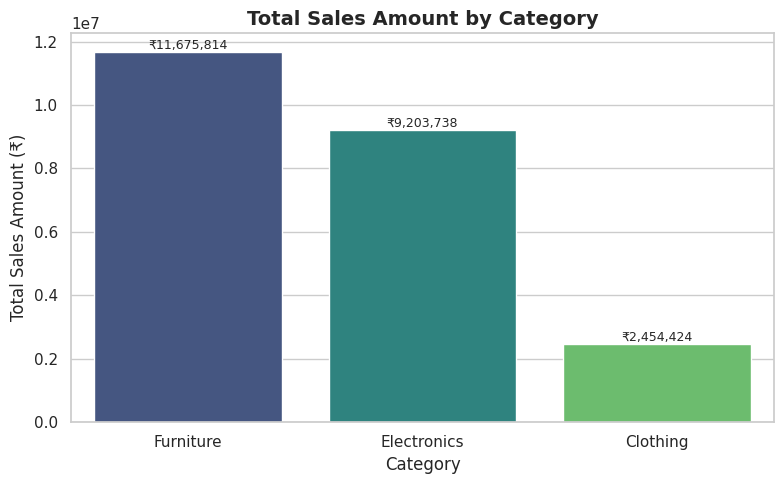

In [16]:
cat_sales = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
ax = sns.barplot(x=cat_sales.index, y=cat_sales.values, hue=cat_sales.index, palette="viridis", legend=False)
ax.set_title("Total Sales Amount by Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Category"); ax.set_ylabel("Total Sales Amount (₹)")
for i, v in enumerate(cat_sales.values):
    ax.text(i, v, f"₹{v:,.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

**Insight:** Furniture generates the most revenue, followed closely by Electronics. Clothing trails well behind both — likely due to a much lower average order value per item.

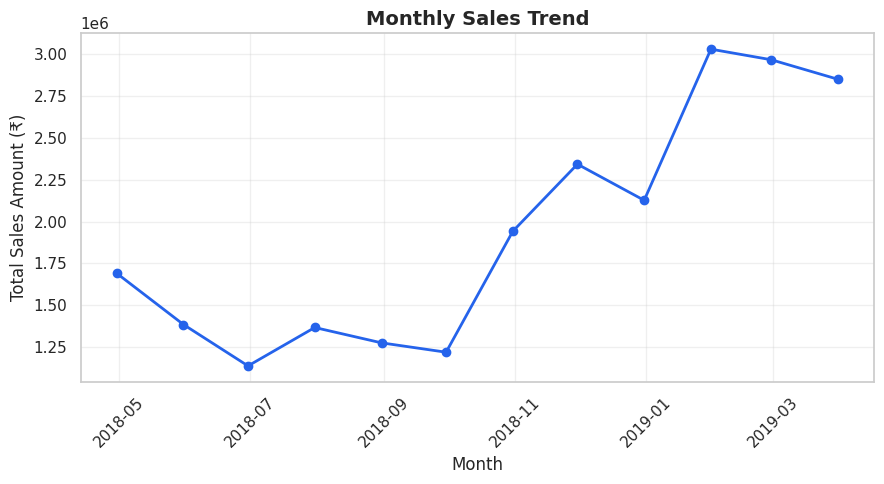

In [17]:
monthly = df.set_index("Order_Date").resample("ME")["Amount"].sum()
plt.figure(figsize=(9,5))
plt.plot(monthly.index, monthly.values, marker="o", color="#2563eb", linewidth=2)
plt.title("Monthly Sales Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month"); plt.ylabel("Total Sales Amount (₹)")
plt.xticks(rotation=45); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** Sales fluctuate month to month without a strong single trend, with a few standout peaks — worth investigating for promotions or seasonal effects.

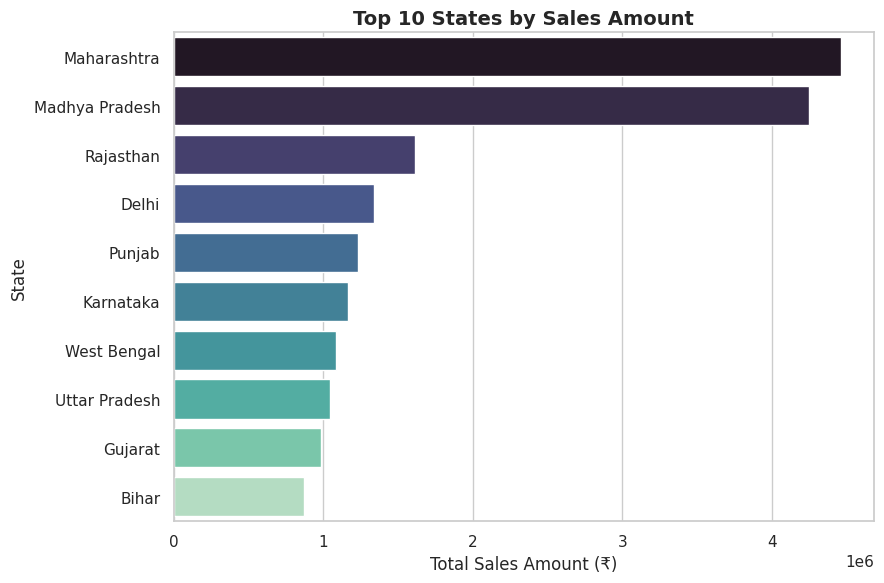

In [18]:
state_sales = df.groupby("State")["Amount"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(9,6))
ax = sns.barplot(y=state_sales.index, x=state_sales.values, hue=state_sales.index, palette="mako", legend=False, orient="h")
ax.set_title("Top 10 States by Sales Amount", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Sales Amount (₹)"); ax.set_ylabel("State")
plt.tight_layout()
plt.show()

**Insight:** Maharashtra and Madhya Pradesh lead by a wide margin over the rest of the top 10 states.

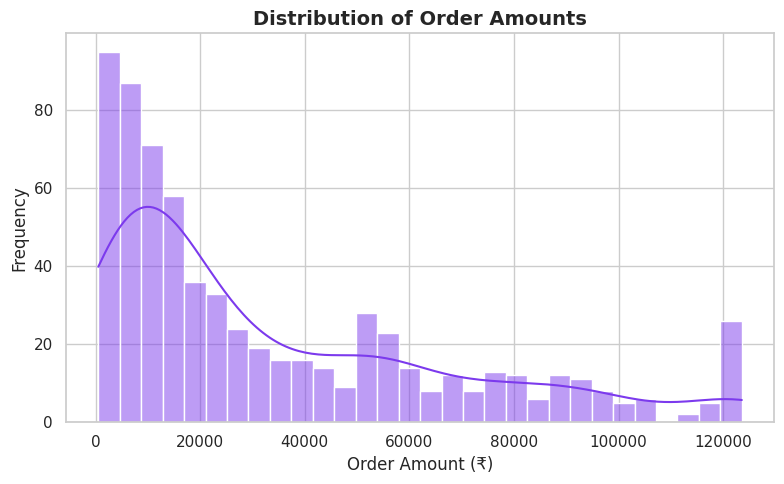

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=30, kde=True, color="#7c3aed")
plt.title("Distribution of Order Amounts", fontsize=14, fontweight="bold")
plt.xlabel("Order Amount (₹)"); plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Insight:** Order amounts are right-skewed — most orders are relatively low value, with a long tail of high-value Furniture/Electronics orders.

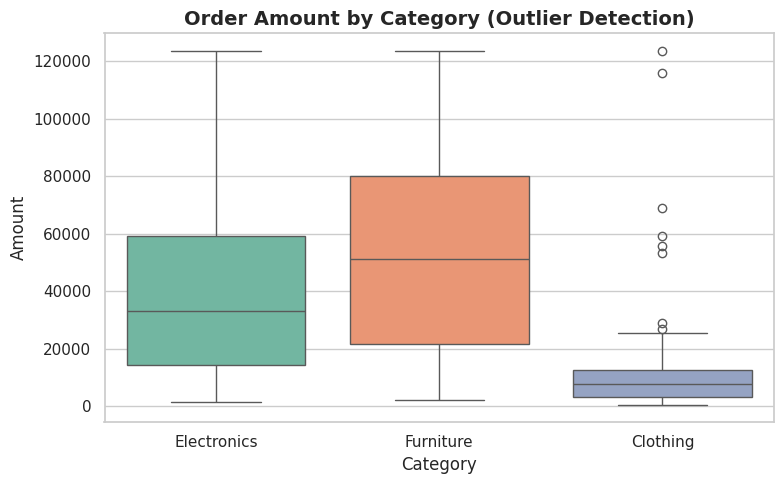

In [20]:
plt.figure(figsize=(8,5))
ax = sns.boxplot(x="Category", y="Amount", hue="Category", data=df, palette="Set2", legend=False)
ax.set_title("Order Amount by Category (Outlier Detection)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Insight:** Furniture shows the widest spread and the most high-end outliers, consistent with it being a big-ticket category. A handful of Amount outliers were capped during cleaning using the IQR method.

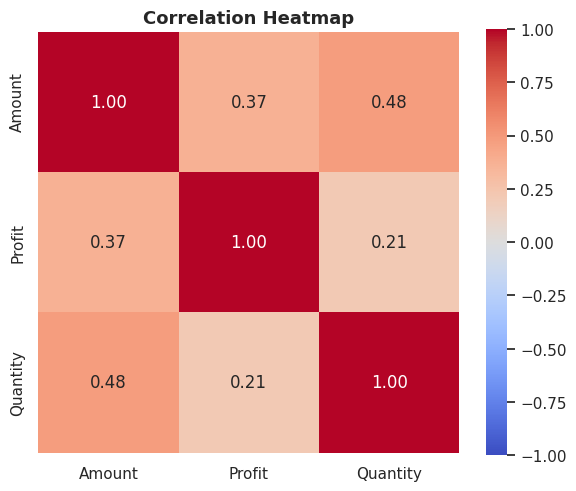

In [21]:
corr = df[["Amount", "Profit", "Quantity"]].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, square=True)
plt.title("Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Insight:** Amount and Profit are positively correlated, as expected — Quantity shows little to no relationship with either, suggesting profitability is driven more by product category/pricing than order size.

## 5. Key Findings & Conclusion

1. **Furniture drives the most revenue** (₹11.7M) but **Electronics is the most profitable category** in total profit, despite lower revenue — its margins are healthier.
2. **Clothing underperforms** on both revenue and profit, and may need a pricing or promotion review.
3. **Maharashtra and Madhya Pradesh** are the top two states by sales, together contributing a disproportionate share of revenue versus other states.
4. **Order amounts are right-skewed**, with a long tail of large Furniture/Electronics purchases — the IQR-based outlier capping during cleaning kept a handful of clear data-entry errors from distorting the analysis.
5. **Quantity is not a strong driver of profit** — the correlation heatmap shows Amount/Profit move together, but Quantity is largely independent of both, suggesting profit is driven by product mix and pricing rather than order size.

**Business takeaway:** Prioritize marketing/inventory investment in Electronics (best margins) and Furniture (best revenue), while investigating whether Clothing pricing or product mix can be improved.
